# Minimum, Maximum, Mixture

In the last chapter, we computed distributions of sums. Here, we'll compute distributions of minimums and maximums, and use them to solve both Forward and Inverse Problems. 

Then, we'll look at distributions that are mixtures of other distributions, which can be very helpful. 

First, let's learn a powerful tool for working with distributions, the cumulative distribution function. 

## Cumulative Distribution Functions

CDF can serve as an alternative to Pmf. For an example, let's use the posterior from the Euro problem:

In [1]:
import numpy as np
from empiricaldist import Pmf

hypos = np.linspace(0, 1, 101)
pmf = Pmf(1, hypos)
data = 140, 250

Here's the update:

In [2]:
from scipy.stats import binom

def update_binomial(pmf, data):
    k, n = data
    xs = pmf.qs
    likelihood = binom.pmf(k, n, xs)
    pmf *= likelihood
    pmf.normalize()

update_binomial(pmf, data)

cumulative = pmf.cumsum()

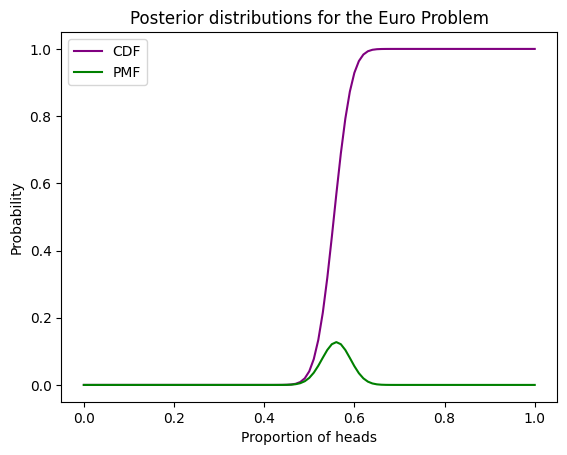

In [8]:
import matplotlib.pyplot as plt

cumulative.plot(label='CDF', color = 'purple')
pmf.plot(label='PMF', color = 'green')
plt.xlabel('Proportion of heads')
plt.ylabel('Probability')
plt.title('Posterior distributions for the Euro Problem')  
plt.legend()
plt.show()

The range of CDF is always from 0 to 1. This is in contrast to the PMF which allows for any probability to be the maximum. 

In [9]:
cumulative[.61]

np.float64(0.9638303193984252)

Using the cumsum, we can see that the total probability of all quantities less that or equal to .61 is 96%. 

We can also go the other way to look up a probability and get a corresponding quantile. 

In [10]:
from scipy.interpolate import interp1d

ps = cumulative.values
qs = cumulative.index

interp = interp1d(ps, qs)
interp(.96)

array(0.60890171)

You can also use a pmf to made a cdf:

In [11]:
cdf = pmf.make_cdf()

cdf[.61]

np.float64(0.9638303193984252)

To look up a quantity, call a cdf as a function using parentheses:

In [12]:
cdf(.615)

array(0.96383032)

Going the other way, you can look up a quantile to look up cumulative probability and get the corresponding quantity:

In [13]:
cdf.quantile(.96)

array(0.61)

Cdf also provides a credible_interval, which computes a credible interval that contains a given probability:

In [14]:
print(cdf.credible_interval(.9))

print(cdf.credible_interval(.95))

print(cdf.credible_interval(.99))

[0.51 0.61]
[0.5  0.62]
[0.48 0.64]


You can also go from cdf to pmf:

In [15]:
pmf = cdf.make_pmf()

## Best Three of Four

In Dungeons and Dragons, each character has six attributes: strength, intelligence, wisdon, dexterity, constitutions, and charisma. 

To generate a new character, players roll four 6-sided dice and add up the highest (best) three results. 

Let's simulate this:

In [16]:
from utils import make_die

die = make_die(6)
dice = [die] * 3

In [17]:
from utils import add_dist_seq

pmf_3d6 = add_dist_seq(dice)

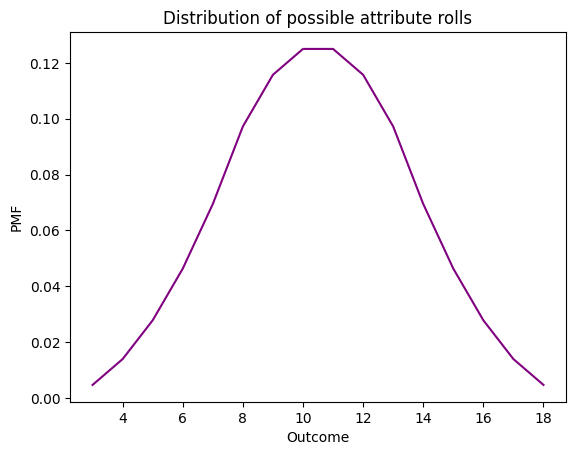

In [19]:
pmf_3d6.plot(color = 'purple')
plt.xlabel('Outcome')
plt.ylabel('PMF')
plt.title('Distribution of possible attribute rolls')  
plt.show()

Let's simulate 10,000 rolls

In [22]:
n = 10000 #10,000 rolls
a = np.random.randint(1, 7, size = (n, 4)) # outcomes 1 to 6, 4 columns (rolls)

a.sort(axis = 1) # find the best three outcomes and sort them
t = a[:,1:].sum(axis = 1) # select the last three columns
pmf_best3 = pmf.from_seq(t) # set 't' as an array and compute a pmf

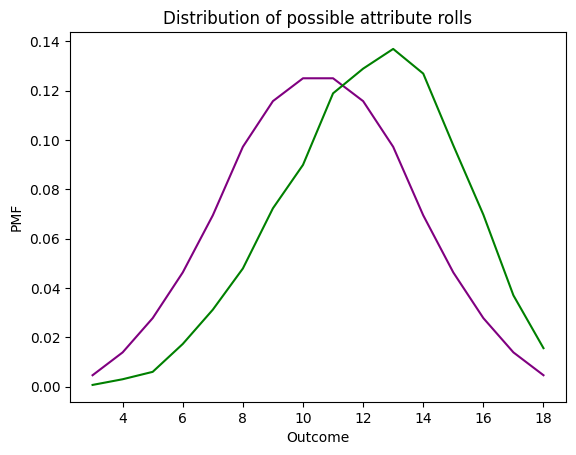

In [23]:
pmf_3d6.plot(label = 'sum of 3 dice', color = 'purple')
pmf_best3.plot(label = 'best 3 of 4', color = 'green')
plt.xlabel('Outcome')
plt.ylabel('PMF')
plt.title('Distribution of possible attribute rolls')  
plt.show()

## Maximum

To compute the distribution of a maximum or minimum, we can use the CDF. 

In [24]:
cdf_best3 = pmf_best3.make_cdf()

Remember, cdf(x) is teh sum of probabilities for quantities less than or equal to x. 

Now, let's draw 6 values from the distribution. The probability that all 6 of them are less than or equal to x if Cdf(x) raised to the 6th power, which we can compute like this:

In [26]:
cdf_best3**6

3     1.176490e-19
4     2.565726e-15
5     8.329720e-13
6     3.874205e-10
7     3.886314e-08
8     1.426567e-06
9     3.223807e-05
10    3.730131e-04
11    3.369862e-03
12    1.889745e-02
13    7.753166e-02
14    2.250264e-01
15    4.571688e-01
16    7.231032e-01
17    9.099754e-01
18    1.000000e+00
Name: , dtype: float64

If all the values are less than or equal to x, that mean that their maximum is less than or equal to x. So, the result is the cdf of their max. 

In [29]:
from empiricaldist import Cdf

cdf_max6 = Cdf(cdf_best3**6)

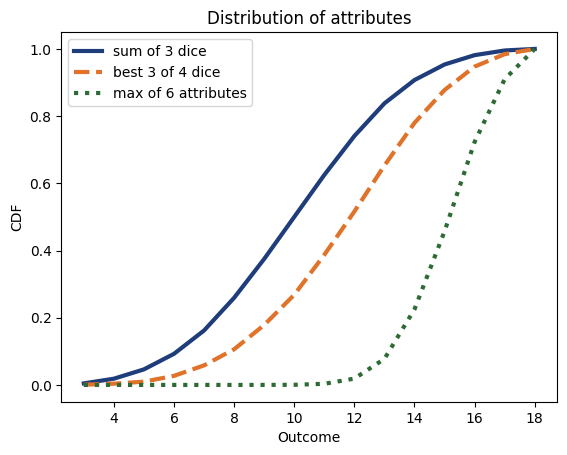

In [33]:
cdf_3d6 = pmf_3d6.make_cdf()   # CDF of the plain sum of 3 dice

cdf_3d6.plot(label='sum of 3 dice', color='#1f3d7a', linestyle='-', linewidth=3)
cdf_best3.plot(label='best 3 of 4 dice', color='#e0722a', linestyle='--', linewidth=3)
cdf_max6.plot(label='max of 6 attributes', color='#2e6b34', linestyle=':', linewidth=3)

plt.xlabel('Outcome')
plt.ylabel('CDF')
plt.title('Distribution of attributes')
plt.legend()
plt.show()

## Minimum

In the previous section we computed the distribution of a character's best attribute. Now let's do the worst. 

To do this we will compute the complementary CDF:

In [36]:
prob_gt = 1 - cdf_best3

If we draw 6 vallues, the prob that all 6 exceed x is:

In [39]:
prob_gt6 = prob_gt**6

If all 6 exceed x, that means their minimum exceeds x, so prob_gt6 is the complementary CDF of the minimum. So, we can compute the minimum like this:

In [40]:
prob_le6 = 1 - prob_gt6

The result is a series that represents the CDF minimum of six attributes. 

In [44]:
cdf_min6 = Cdf(prob_le6)

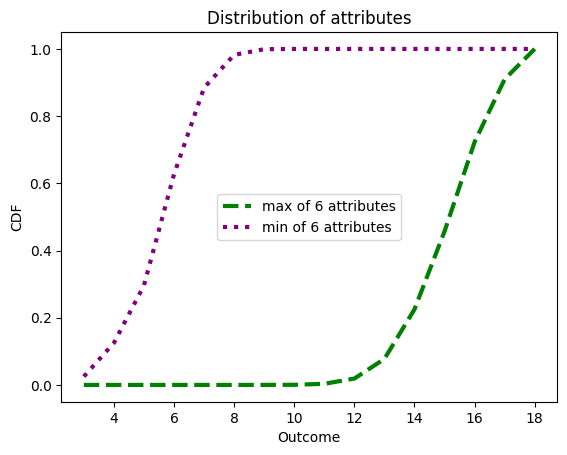

In [50]:
cdf_max6.plot(label='max of 6 attributes', color='green', linestyle='--', linewidth=3)
cdf_min6.plot(label='min of 6 attributes', color='purple', linestyle=':', linewidth=3)

plt.xlabel('Outcome')
plt.ylabel('CDF')
plt.title('Distribution of attributes')
plt.legend()
plt.show()

Cdf also has the function min_dist that does the same computation. 

In [54]:
cdf_min_dist6 = cdf_best3.min_dist(6)

# confirm it 

np.allclose(cdf_min_dist6, cdf_min6) # comes back false. not sure why

False

## Mixture

Here we'll see how to compute a distribution that is a mixture of other distributions. Then, we'll talk about how those mixture can be used to make predictions. 

Another Dungeons and Dragons example:

- Suppose your character is armed with a dagger in one hand and a short sword in another.
- During each round, you attack with one of your weapons, randomly chosen.
- The dagger causes one 4-sided die of damage; the short sword causes one 6-sided die of damage.

What is the distribution of the damage you inflict?